## LULC Dataset from USGS
#### Data: https://www.sciencebase.gov/catalog/item/66c61211d34e0338828a7fe8
#### Lookup table below is derived from the metadata

In [2]:
import geopandas as gpd
import rasterio
from matplotlib import pyplot as plt
import glob
import pandas as pd
import rasterio.features
import seaborn as sns
import os

In [3]:
lucas_landuse_lookup = {
        11: "Open Water",
        12: "Ice and Snow",
        21: "Developed Open Space",
        22: "Developed Low Intensity",
        23: "Developed Medium Intensity",
        24: "Developed High Intensity",
        25: "Developed Transportation",
        31: "Barren",
        65: "Shrubland",
        71: "Grassland",
        81: "Pasture/Hay",
        82: "Crops",
        90: "Forested wetlands",
        95: "Herbaceous wetlands",
        180: "Forest: Pinyon/Juniper",
        200: "Forest: Coastal Douglas-fir",
        220: "Forest: Ponderosa pine",
        240: "Forest: Western White Pine",
        260: "Forest: Fir/Spruce/Hemlock",
        280: "Forest: Lodgepole Pine",
        300: "Forest: Hemlock/Sitka Spruce",
        340: "Forest: Redwood",
        360: "Forest: Other Western Softwood",
        370: "Forest: California Mixed Conifer",
        700: "Forest: Elm/Ash/Cottonwood",
        900: "Forest: Aspen/Birch",
        910: "Forest: Alder/Maple",
        920: "Forest: Western Oak",
        940: "Forest: Tanoak/Laurel",
        1000: "Postfire Shrub",
        -9999: "No data"
    }
def rast_to_vect(path):
    src = rasterio.open(path)
    # plt.imshow(src.read(1), cmap='tab20')
    # Converting Raster LULC file to polygon shp file
    
    image = src.read(1)
    results = (
            {'properties': {'raster_val': v, 'label':lucas_landuse_lookup[v], "year": path[-8:-4]}, 'geometry': s}
            for i, (s, v) 
            in enumerate(rasterio.features.shapes(image, mask=None, transform=src.transform))
        )

    geoms = list(results)
    gdf = gpd.GeoDataFrame.from_features(geoms)
    # gdf = gdf.dissolve(by='label')
    # set the crs of geodataframe to source crs first and then covert it to the desired crs
    gdf= gdf.set_crs(src.crs)
    return gdf

In [ ]:
# rasterpath = r"C:\Users\pranj\Downloads\Historical\Historical\*.tif"
# lulcs = []
# for path in glob.glob(rasterpath):
#     lulcs.append(rast_to_vect(path))
# lulc_vect = gpd.GeoDataFrame(pd.concat(lulcs))

In [ ]:
# # os.mkdir( r"C:\Users\pranj\Downloads\Historical\Historical\Vector_LULC")
# lulc_vect.to_file( r"C:\Users\pranj\Downloads\Historical\Historical\Vector_LULC\lulc_vector.shp")

In [4]:
lulc_vect = gpd.read_file(r"C:\Users\pranj\Downloads\Historical\Historical\Vector_LULC\lulc_vector.shp")

In [5]:
lulc_vect = lulc_vect[lulc_vect.year.astype(int)>2000]
lulc_vect = lulc_vect.reset_index()

In [6]:
lulc_vect = lulc_vect[lulc_vect['label']!="No data"]

In [7]:
%store -r date_buffer

In [8]:
date_buffer = date_buffer[['BRIGHTNESS','ACQ_DATE','BRIGHT_T31','FRP', 'DAYNIGHT', 'TYPE', 'geometry', 'ordinal date',
       'year_left','BurnDate','geom_id','neighbors', 'neigh_burndates',"area_sqkm"]]

In [9]:
lulc_vect = lulc_vect.to_crs(date_buffer.crs)
lulc_vect.year = lulc_vect.year.astype(int)

In [10]:
ar=[]
date_buffer['original_geom'] = date_buffer.geometry
for yr in lulc_vect.year.unique():
    joined = gpd.overlay(date_buffer[date_buffer.year_left==yr].to_crs("EPSG:3310"),lulc_vect[lulc_vect.year==yr].to_crs("EPSG:3310"), how="intersection")
    joined['lulc_area'] = joined.geometry.area/10**6
    ar.append(joined)
fire_lulc = gpd.GeoDataFrame(pd.concat(ar))


C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [11]:
fire_lulc_max = fire_lulc.set_index('geometry').loc[fire_lulc.set_index('geometry').groupby('original_geom')['lulc_area'].idxmax()].reset_index()
fire_lulc_max = fire_lulc_max.to_crs("epsg:4326")

In [12]:
fire_lulc_max.head()

,geometry,BRIGHTNESS,ACQ_DATE,BRIGHT_T31,FRP,DAYNIGHT,TYPE,ordinal date,year_left,BurnDate,geom_id,neighbors,neigh_burndates,area_sqkm,original_geom,index,raster_val,label,year,lulc_area
0,"POLYGON ((-120.50858 34.54408, -120.50447 34.5...",380.3,2002-06-16,299.0,220.8,N,0,167,2002,167.0,2161.0,"[2124, 2131, 2137, 2156, 2157, 2165]","[170, 168, 163, 170, 166, 166]",18.684511,"POLYGON ((-120.50852 34.53507, -120.50858 34.5...",267878,65.0,Shrubland,2002,0.840657
1,"POLYGON ((-120.51498 34.54278, -120.50408 34.5...",342.8,2002-06-16,293.3,68.6,N,0,167,2002,167.0,2161.0,"[2124, 2131, 2137, 2156, 2157, 2165]","[170, 168, 163, 170, 166, 166]",18.684511,"POLYGON ((-120.51492 34.53377, -120.51498 34.5...",267878,65.0,Shrubland,2002,0.917225
2,"POLYGON ((-120.58926 34.5596, -120.57842 34.56...",415.2,2016-09-20,296.9,2488.3,N,3,264,2016,262.0,37896.0,[37897],[266],0.393263,"POLYGON ((-120.58922 34.55397, -120.58928 34.5...",1620838,11.0,Open Water,2016,0.752710
3,"POLYGON ((-120.58959 34.57368, -120.57868 34.5...",357.5,2016-09-19,301.9,148.5,N,0,263,2016,262.0,37896.0,[37897],[266],34.396433,"POLYGON ((-120.58952 34.56467, -120.58959 34.5...",1602224,65.0,Shrubland,2016,0.520438
4,"POLYGON ((-120.58748 34.57849, -120.5823 34.57...",334.1,2016-09-20,291.4,230.9,N,0,264,2016,263.0,37889.0,"[37881, 37883, 37884, 37885, 37891, 37894]","[264, 266, 265, 265, 266, 264]",34.003169,"POLYGON ((-120.58742 34.57057, -120.58749 34.5...",1602224,65.0,Shrubland,2016,0.971246


In [13]:
fire_lulc_max['geometry'] = fire_lulc_max['original_geom']
fire_lulc_max = fire_lulc_max.drop('original_geom',axis=1)
fire_lulc_max.head()

,geometry,BRIGHTNESS,ACQ_DATE,BRIGHT_T31,FRP,DAYNIGHT,TYPE,ordinal date,year_left,BurnDate,geom_id,neighbors,neigh_burndates,area_sqkm,index,raster_val,label,year,lulc_area
0,"POLYGON ((-120.50852 34.53507, -120.50858 34.5...",380.3,2002-06-16,299.0,220.8,N,0,167,2002,167.0,2161.0,"[2124, 2131, 2137, 2156, 2157, 2165]","[170, 168, 163, 170, 166, 166]",18.684511,267878,65.0,Shrubland,2002,0.840657
1,"POLYGON ((-120.51492 34.53377, -120.51498 34.5...",342.8,2002-06-16,293.3,68.6,N,0,167,2002,167.0,2161.0,"[2124, 2131, 2137, 2156, 2157, 2165]","[170, 168, 163, 170, 166, 166]",18.684511,267878,65.0,Shrubland,2002,0.917225
2,"POLYGON ((-120.58922 34.55397, -120.58928 34.5...",415.2,2016-09-20,296.9,2488.3,N,3,264,2016,262.0,37896.0,[37897],[266],0.393263,1620838,11.0,Open Water,2016,0.752710
3,"POLYGON ((-120.58952 34.56467, -120.58959 34.5...",357.5,2016-09-19,301.9,148.5,N,0,263,2016,262.0,37896.0,[37897],[266],34.396433,1602224,65.0,Shrubland,2016,0.520438
4,"POLYGON ((-120.58742 34.57057, -120.58749 34.5...",334.1,2016-09-20,291.4,230.9,N,0,264,2016,263.0,37889.0,"[37881, 37883, 37884, 37885, 37891, 37894]","[264, 266, 265, 265, 266, 264]",34.003169,1602224,65.0,Shrubland,2016,0.971246


In [109]:
fire_lulc_max.groupby(['ACQ_DATE','geom_id'])['label'].apply(lambda x:len(x.unique())).unique()

array([ 1,  2,  3,  5,  4,  6,  7, 11,  8, 10,  9], dtype=int64)

In [14]:
fire_lulc_dissolved = fire_lulc_max.dissolve(by=['ACQ_DATE','geom_id'], aggfunc={"FRP": "sum",'BRIGHT_T31':'mean','label': lambda x:list(set(x)),'lulc_area':lambda x:list(set(x)),'year':'first','area_sqkm':'first','ordinal date':'first','BurnDate':'mean'}).reset_index()
fire_lulc_dissolved.head()

,ACQ_DATE,geom_id,geometry,FRP,BRIGHT_T31,label,lulc_area,year,area_sqkm,ordinal date,BurnDate
0,2001-03-22,426.0,"POLYGON ((-121.73997 38.92872, -121.74018 38.9...",19.2,299.3,[Pasture/Hay],[0.8292504505523058],2001,1.857430,81,80.0
1,2001-03-27,358.0,"POLYGON ((-122.19716 39.1709, -122.19743 39.17...",23.0,299.4,[Pasture/Hay],[0.9999999999990978],2001,4.072479,86,87.0
2,2001-04-01,95.0,"POLYGON ((-122.18138 39.5037, -122.18165 39.51...",40.3,305.5,[Developed Low Intensity],[0.872120759503792],2001,2.026472,91,88.0
3,2001-04-01,114.0,"POLYGON ((-122.15598 39.498, -122.15625 39.507...",34.5,304.4,[Pasture/Hay],[1.0000000000036962],2001,4.421854,91,72.0
4,2001-04-01,385.0,"POLYGON ((-121.47589 38.96513, -121.47607 38.9...",194.6,296.8,[Crops],[0.7242294776237265],2001,0.371320,91,77.0


In [ ]:
%store fire_lulc_dissolved

Stored 'fire_lulc_dissolved' (GeoDataFrame)


: 

<AxesSubplot: xlabel='label'>

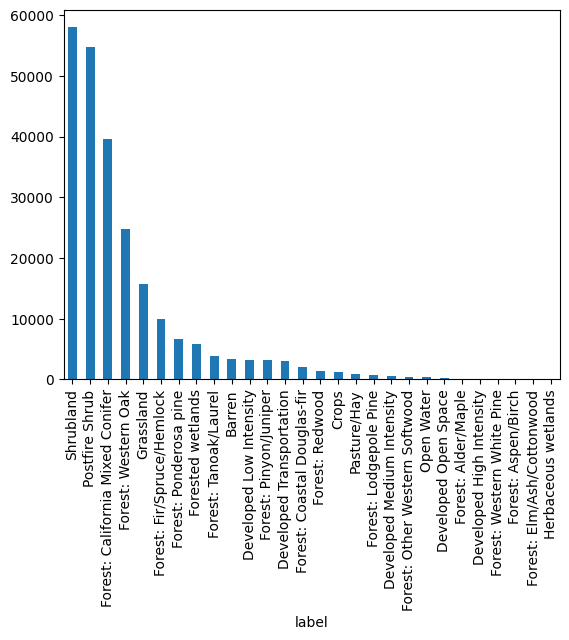

In [ ]:
fire_lulc.label.value_counts().plot.bar()

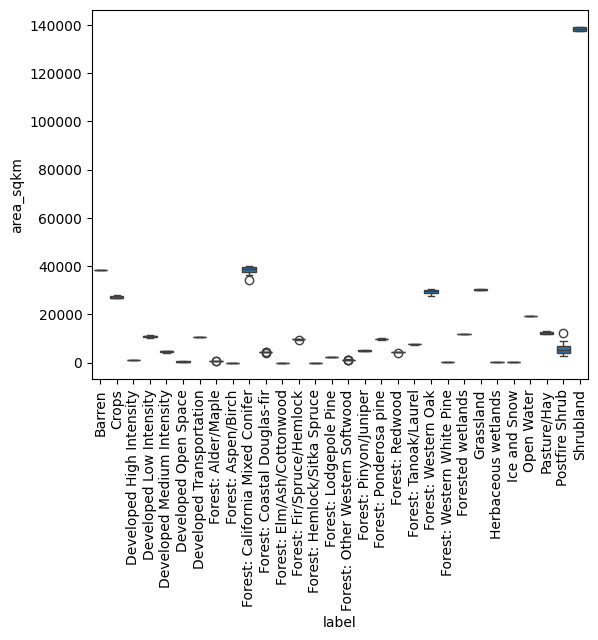

In [64]:
lulc_vect = lulc_vect.to_crs("EPSG:9311") #9311 is crs espcially for US for area calculation purpose
lulc_vect['area_sqkm'] = lulc_vect['geometry'].area/10**6
sns.boxplot(x='label', y='area_sqkm',data = lulc_vect)
plt.xticks(rotation=90);

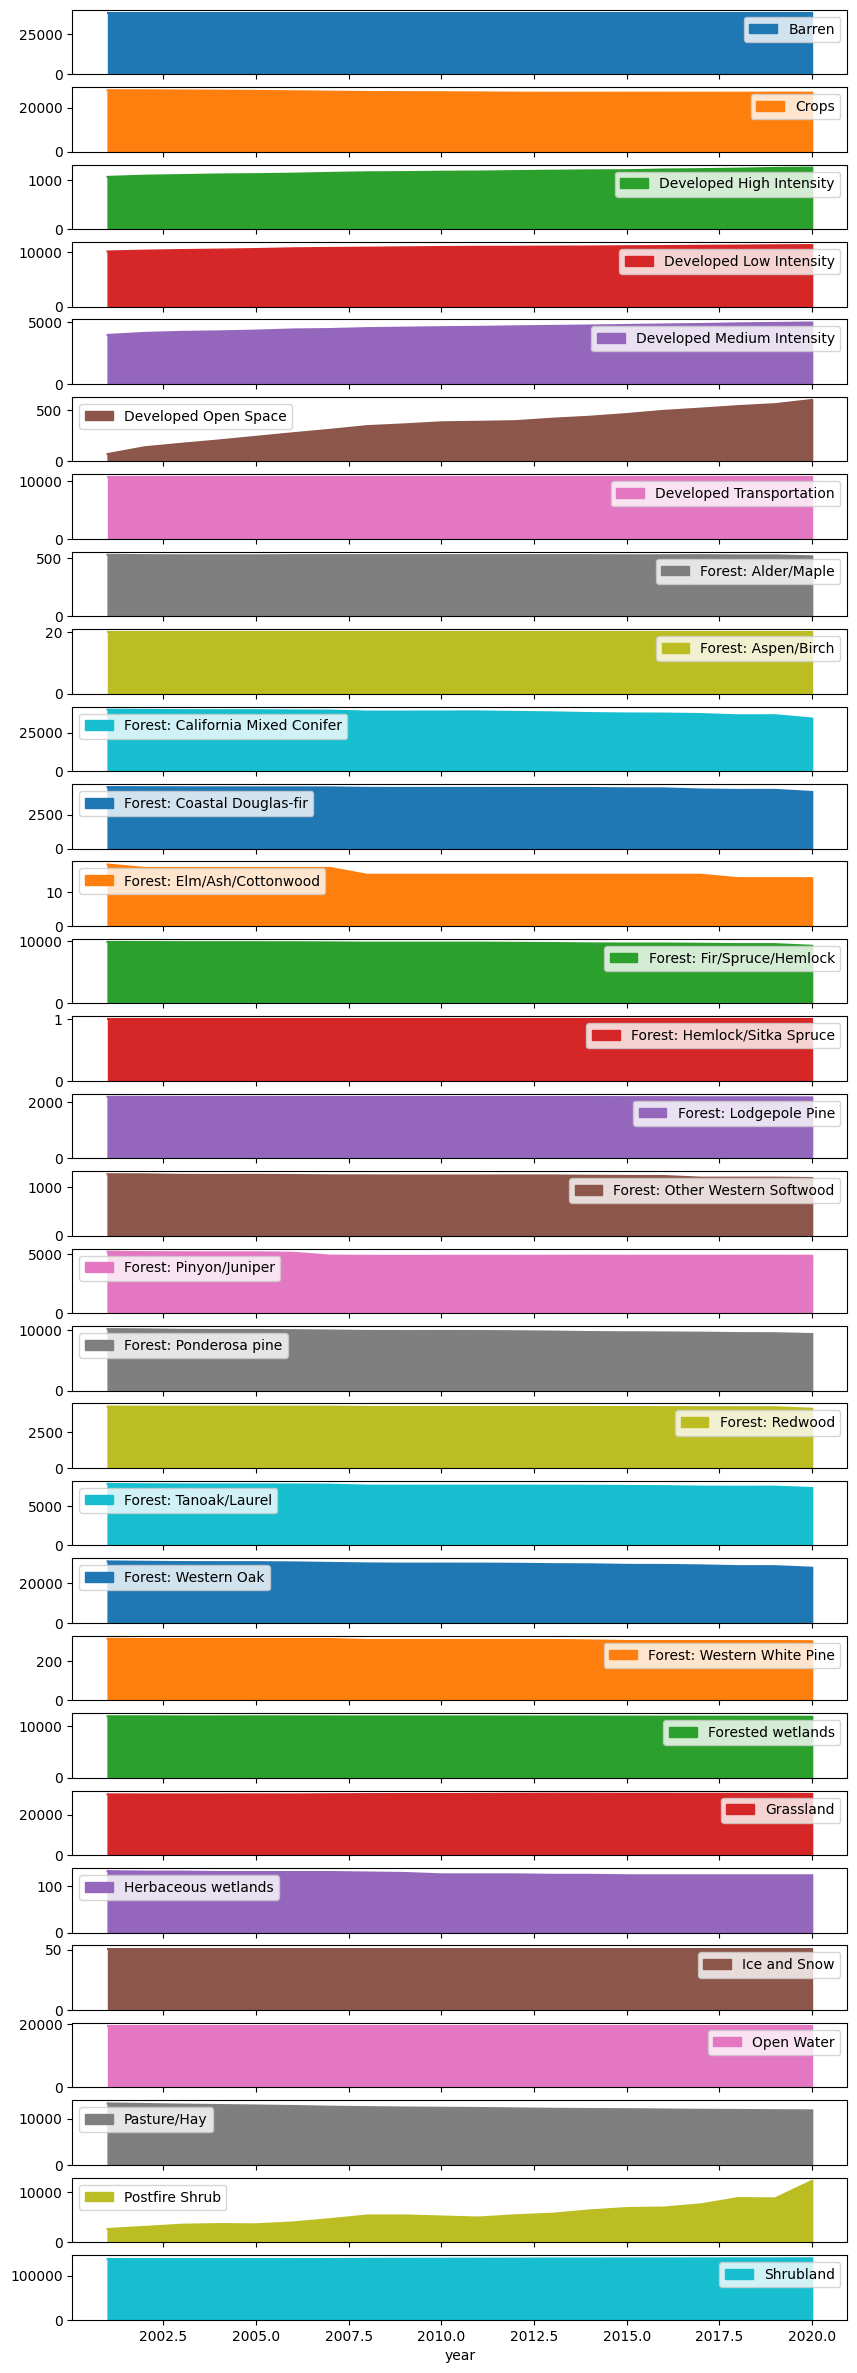

In [ ]:
lulc_vect.pivot_table(index = 'year', columns = 'label' , values = 'area_sqkm').plot(kind = 'area', subplots = True,figsize=(10,30));

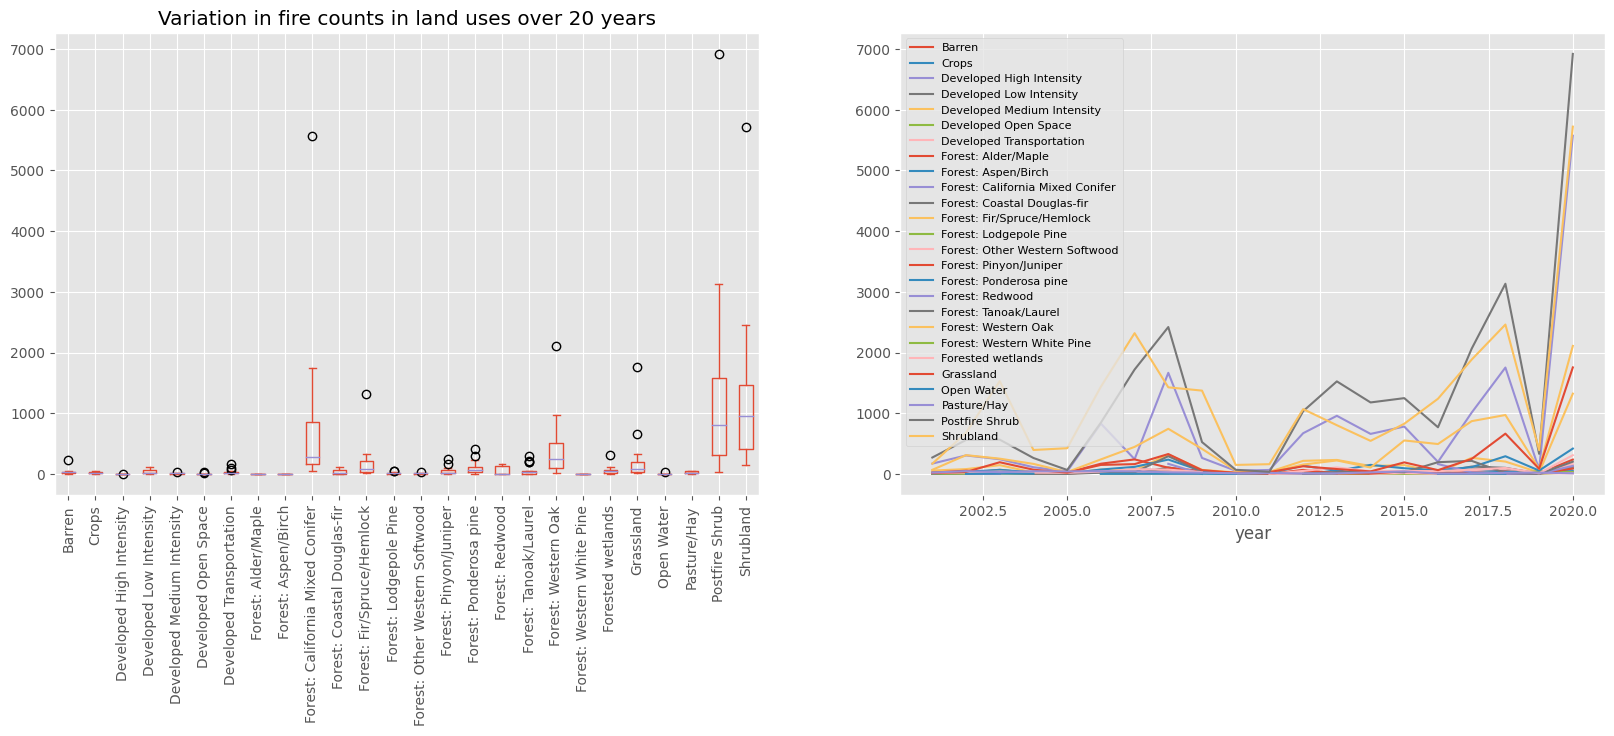

In [73]:
import matplotlib
matplotlib.style.use('ggplot')
fig,ax=plt.subplots(1,2,figsize=(20,6))
ax[0].set_title('Variation in fire counts in land uses over 20 years')
# ax[0].set_xticks(rotation=90)
fire_lulc_max.groupby(['year'])['label'].value_counts().unstack().plot.box(ax=ax[0],rot=90)
fire_lulc_max.groupby(['year'])['label'].value_counts().unstack().plot(ax=ax[1])
plt.legend(fontsize=8)

In [ ]:
%store lulc_vect fire_lulc

Stored 'lulc_vect' (GeoDataFrame)
Stored 'fire_lulc' (GeoDataFrame)


: 

In [1]:
# lulc_vect[lulc_vect.year==2001].reset_index().explore(column='label')